# Ejercicio 5: Bernstein-Vazirani con ruido bit-flip

**Juan Sosa** — Computación Cuántica 2, Examen 1

In [1]:
%pip install qiskit qiskit-aer -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
from collections import Counter
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

simulator = AerSimulator()

---
## Parte 1 – Algoritmo sin ruido

### (a) Elegir n=4 y generar una cadena secreta s aleatoria.

In [3]:
n = 4

# Generamos s aleatoriamente (cadena de n bits)
random.seed(42)
s = ''.join([str(random.randint(0, 1)) for _ in range(n)])
print(f"Cadena secreta: s = {s}")

Cadena secreta: s = 0010


### (b) Construir el circuito de Bernstein-Vazirani para ese s.

El circuito usa n qubits de entrada + 1 qubit auxiliar:
1. Preparamos $|0\rangle^{\otimes n}|1\rangle$
2. Hadamard a todos los n+1 qubits
3. Oráculo: CNOT del qubit i al auxiliar para cada bit $s_i = 1$
4. Hadamard a los primeros n qubits
5. Medimos los primeros n qubits

In [4]:
def construir_bv(s):
    """Construye el circuito de Bernstein-Vazirani para la cadena s."""
    n = len(s)
    # n qubits de entrada + 1 auxiliar, n bits clasicos para medicion
    qc = QuantumCircuit(n + 1, n)

    # Paso 1: poner el auxiliar en |1>
    qc.x(n)

    # Paso 2: Hadamard a todos
    qc.h(range(n + 1))
    qc.barrier()

    # Paso 3: Oraculo — CNOT controlado por los qubits donde s_i = 1
    for i in range(n):
        if s[i] == '1':
            qc.cx(i, n)
    qc.barrier()

    # Paso 4: Hadamard a los primeros n qubits
    qc.h(range(n))
    qc.barrier()

    # Paso 5: medir los primeros n qubits
    qc.measure(range(n), range(n))

    return qc

qc_ideal = construir_bv(s)
print(qc_ideal.draw())

     ┌───┐      ░       ░ ┌───┐ ░ ┌─┐         
q_0: ┤ H ├──────░───────░─┤ H ├─░─┤M├─────────
     ├───┤      ░       ░ ├───┤ ░ └╥┘┌─┐      
q_1: ┤ H ├──────░───────░─┤ H ├─░──╫─┤M├──────
     ├───┤      ░       ░ ├───┤ ░  ║ └╥┘┌─┐   
q_2: ┤ H ├──────░───■───░─┤ H ├─░──╫──╫─┤M├───
     ├───┤      ░   │   ░ ├───┤ ░  ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░───┼───░─┤ H ├─░──╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐ ░ └───┘ ░  ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░─┤ X ├─░───────░──╫──╫──╫──╫─
     └───┘└───┘ ░ └───┘ ░       ░  ║  ║  ║  ║ 
c: 4/══════════════════════════════╩══╩══╩══╩═
                                   0  1  2  3 


### (c) Ejecutar en simulador ideal y verificar que el resultado es exactamente s.

In [5]:
# Ejecutamos con 1024 disparos
resultado = simulator.run(qc_ideal, shots=1024).result()
conteos = resultado.get_counts()

# Qiskit devuelve los bits en orden inverso, asi que invertimos
resultado_medido = list(conteos.keys())[0][::-1]

print(f"Resultado medido: {resultado_medido}")
print(f"Cadena secreta:   {s}")
print(f"¿Coinciden? {resultado_medido == s}")
print(f"Conteos: {conteos}")

Resultado medido: 0010
Cadena secreta:   0010
¿Coinciden? True
Conteos: {'0100': 1024}


---
## Parte 2 – Introducción de ruido bit-flip

### (a) Modificar el circuito para simular un canal de bit-flip.

El ruido actúa después del oráculo: con probabilidad $p$ cada qubit se voltea (compuerta X), con probabilidad $1-p$ queda igual.

Como en el circuito ideal el resultado antes de la medición es determinístico ($|s\rangle$), un bit-flip antes de la medición es equivalente a voltear cada bit del resultado con probabilidad $p$. Simulamos esto de forma directa para mayor eficiencia.

In [6]:
def simular_bv_con_ruido(s, p, num_shots):
    """
    Simula BV con ruido bit-flip.
    Para cada disparo, tomamos el resultado ideal (s) y
    volteamos cada bit independientemente con probabilidad p.
    """
    n = len(s)
    resultados = []

    for _ in range(num_shots):
        # Partimos del resultado ideal
        bits = list(s)
        # Aplicamos bit-flip a cada qubit con probabilidad p
        for i in range(n):
            if random.random() < p:
                bits[i] = '0' if bits[i] == '1' else '1'
        resultados.append(''.join(bits))

    return resultados

### (b) Fijar $p = 0.1$, ejecutar 1024 veces y calcular tasa de éxito.

In [7]:
p = 0.1
num_shots = 1024

resultados = simular_bv_con_ruido(s, p, num_shots)
aciertos = sum(1 for r in resultados if r == s)
tasa = aciertos / num_shots

print(f"p = {p}, shots = {num_shots}")
print(f"Aciertos: {aciertos}/{num_shots}")
print(f"Tasa de éxito: {tasa:.4f}")
print(f"Valor teórico (1-p)^n = {(1-p)**n:.4f}")

p = 0.1, shots = 1024
Aciertos: 692/1024
Tasa de éxito: 0.6758
Valor teórico (1-p)^n = 0.6561


### (c) Repetir para varios valores de $p$.

In [8]:
valores_p = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
num_shots = 1024
tasas = []

for p_val in valores_p:
    resultados = simular_bv_con_ruido(s, p_val, num_shots)
    aciertos = sum(1 for r in resultados if r == s)
    tasa = aciertos / num_shots
    tasas.append(tasa)

# Guardamos para usar despues
tasas_parte2 = dict(zip(valores_p, tasas))

### (d) Tabla de tasa de éxito en función de $p$.

     p |  Tasa experimental |  (1-p)^n teórico
-----------------------------------------------
  0.00 |             1.0000 |           1.0000
  0.05 |             0.8359 |           0.8145
  0.10 |             0.6523 |           0.6561
  0.15 |             0.5010 |           0.5220
  0.20 |             0.3857 |           0.4096
  0.25 |             0.3477 |           0.3164
  0.30 |             0.2500 |           0.2401


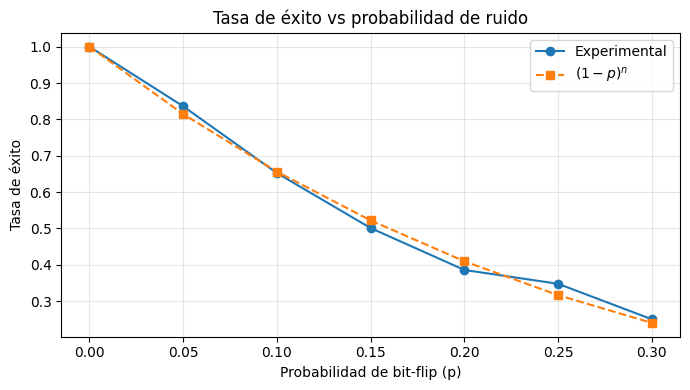

In [9]:
import matplotlib.pyplot as plt

# Tabla
print(f"{'p':>6} | {'Tasa experimental':>18} | {'(1-p)^n teórico':>16}")
print("-" * 47)
for p_val, tasa in zip(valores_p, tasas):
    teorico = (1 - p_val) ** n
    print(f"{p_val:>6.2f} | {tasa:>18.4f} | {teorico:>16.4f}")

# Grafica sencilla
teoricos = [(1 - p_val)**n for p_val in valores_p]

plt.figure(figsize=(7, 4))
plt.plot(valores_p, tasas, 'o-', label='Experimental')
plt.plot(valores_p, teoricos, 's--', label=r'$(1-p)^n$')
plt.xlabel('Probabilidad de bit-flip (p)')
plt.ylabel('Tasa de éxito')
plt.title('Tasa de éxito vs probabilidad de ruido')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Comentario:** La tasa de éxito disminuye conforme $p$ aumenta, siguiendo aproximadamente la curva $(1-p)^n$. Esto tiene sentido porque para que el resultado sea correcto, *ninguno* de los $n$ qubits debe sufrir un bit-flip, y cada uno falla independientemente con probabilidad $p$.

---
## Parte 3 – Mitigación por mayoría (repetición)

### (a) Para $p=0.1$ y $n=4$: ejecutar 5 veces, tomar la moda, repetir 100 veces.

In [10]:
p = 0.1
num_rondas = 100     # cuantas veces repetimos el proceso
repeticiones = 5     # ejecuciones por ronda
aciertos_mitigados = 0

for _ in range(num_rondas):
    # Ejecutamos el circuito ruidoso 5 veces
    resultados_ronda = simular_bv_con_ruido(s, p, repeticiones)

    # Tomamos la moda (resultado mas frecuente)
    conteo = Counter(resultados_ronda)
    moda = conteo.most_common(1)[0][0]

    if moda == s:
        aciertos_mitigados += 1

tasa_mitigada = aciertos_mitigados / num_rondas
print(f"Tasa de éxito con mitigación (5 reps, moda): {tasa_mitigada:.4f}")

Tasa de éxito con mitigación (5 reps, moda): 0.9300


### (b) Comparar con la tasa sin mitigación para $p=0.1$.

In [11]:
tasa_sin = tasas_parte2[0.1]

print(f"Tasa sin mitigación (p=0.1): {tasa_sin:.4f}")
print(f"Tasa con mitigación (p=0.1): {tasa_mitigada:.4f}")
print(f"Mejora: {tasa_mitigada - tasa_sin:+.4f}")
print()
if tasa_mitigada > tasa_sin:
    print("Sí hubo mejora. Tomar la moda de varias ejecuciones reduce el impacto del ruido.")
else:
    print("No hubo mejora significativa.")

Tasa sin mitigación (p=0.1): 0.6523
Tasa con mitigación (p=0.1): 0.9300
Mejora: +0.2777

Sí hubo mejora. Tomar la moda de varias ejecuciones reduce el impacto del ruido.


---
## Parte 4 – Preguntas de análisis

### (a) En el caso ideal (sin ruido), ¿por qué el algoritmo de Bernstein-Vazirani requiere una sola consulta al oráculo para encontrar $s$?

Porque la primera capa de Hadamard crea una superposición de todas las $2^n$ entradas posibles. El oráculo evalúa $f(x) = s \cdot x$ sobre *todas* simultáneamente, codificando la información de $s$ en las fases relativas: el estado queda $(-1)^{s \cdot x}|x\rangle$. La segunda Hadamard convierte esas fases en amplitudes, colapsando el estado exactamente a $|s\rangle$. Así, una sola consulta basta porque el paralelismo cuántico y la interferencia extraen los $n$ bits de $s$ de golpe.

### (b) Si el ruido de bit-flip afecta a un qubit después del oráculo, ¿cómo cambia la probabilidad de obtener el resultado correcto? Da una expresión aproximada.

Cada uno de los $n$ qubits se voltea independientemente con probabilidad $p$. Para obtener $s$ correctamente, *ningún* qubit debe voltearse. La probabilidad de que un qubit individual no se voltee es $(1-p)$, y como son independientes:

$$P(\text{éxito}) = (1 - p)^n$$

Para $p$ pequeño, se puede aproximar como $P \approx 1 - np$ (usando $(1-p)^n \approx e^{-np} \approx 1 - np$).

Verificamos numéricamente:

In [12]:
# Verificacion con los datos de la Parte 2
print(f"{'p':>6} | {'Experimental':>12} | {'(1-p)^n':>8} | {'1 - np':>8}")
print("-" * 44)
for p_val, tasa in tasas_parte2.items():
    exacto = (1 - p_val) ** n
    aprox = 1 - n * p_val
    print(f"{p_val:>6.2f} | {tasa:>12.4f} | {exacto:>8.4f} | {aprox:>8.4f}")

     p | Experimental |  (1-p)^n |   1 - np
--------------------------------------------
  0.00 |       1.0000 |   1.0000 |   1.0000
  0.05 |       0.8359 |   0.8145 |   0.8000
  0.10 |       0.6523 |   0.6561 |   0.6000
  0.15 |       0.5010 |   0.5220 |   0.4000
  0.20 |       0.3857 |   0.4096 |   0.2000
  0.25 |       0.3477 |   0.3164 |   0.0000
  0.30 |       0.2500 |   0.2401 |  -0.2000


### (c) ¿Cuál es la principal desventaja del método de mitigación por mayoría? ¿Funcionaría igual de bien si $p = 0.4$?

La **principal desventaja** es el costo: se necesitan $k$ veces más ejecuciones del circuito (en nuestro caso $k=5$). Esto multiplica el tiempo y los recursos por 5 para obtener un solo resultado mitigado.

Para $p = 0.4$ con $n = 4$, la probabilidad de un solo acierto es $(1-0.4)^4 = 0.6^4 = 0.1296$. Con solo ~13% de aciertos individuales, es muy probable que la moda de 5 intentos **no** sea $s$, porque hay $2^4 = 16$ posibles cadenas compitiendo y el resultado correcto aparece muy pocas veces.

Verificamos:

In [13]:
# Comparamos mitigacion para p = 0.1 vs p = 0.4
for p_test in [0.1, 0.4]:
    aciertos = 0
    for _ in range(500):
        resultados_ronda = simular_bv_con_ruido(s, p_test, 5)
        conteo = Counter(resultados_ronda)
        moda = conteo.most_common(1)[0][0]
        if moda == s:
            aciertos += 1
    print(f"p = {p_test}: tasa mitigada = {aciertos/500:.4f}, "
          f"tasa sin mitigar = {(1-p_test)**n:.4f}")

p = 0.1: tasa mitigada = 0.9160, tasa sin mitigar = 0.6561
p = 0.4: tasa mitigada = 0.1460, tasa sin mitigar = 0.1296


Para $p = 0.4$ la mitigación por mayoría casi no ayuda. Se necesitarían muchas más repeticiones (y aún así, con $p$ tan alto la señal se pierde entre el ruido). La estrategia funciona bien solo cuando $p$ es suficientemente pequeño para que el resultado correcto siga siendo el más probable individualmente.